<a href="https://colab.research.google.com/github/OlexiyBerdichevskie/ML/blob/main/%D0%9B%D0%A0_5_%D0%91%D0%B5%D1%80%D0%B4%D0%B8%D1%87%D0%B5%D0%B2%D1%81%D1%8C%D0%BA%D0%B8%D0%B9_%D0%9E%D0%BB%D0%B5%D0%BA%D1%81%D1%96%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Не зміг бути присутнім на парі, із-за проблем із здоров'єм

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

warnings.filterwarnings("ignore")
plt.style.use("default")

In [6]:
from google.colab import files
import os
uploaded = files.upload()

Saving kaggel_weather_2013_to_2024.csv to kaggel_weather_2013_to_2024.csv


In [7]:
df = pd.read_csv("kaggel_weather_2013_to_2024.csv")

df

,Unnamed: 0,DATE,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
0,0,4/14/2013,37.7,23.1,28.7,35.4,23.1,28.1,39.7,2.0,...,13,15,1496.69,917.07,1139.39,1405.38,917.07,1115.57,14.6,147.178118
1,1,4/15/2013,37.5,21.1,28.6,35.3,21.1,28.0,41.7,0.0,...,13,16,1563.75,879.87,1192.62,1472.01,879.87,1167.60,16.4,151.731061
2,2,4/16/2013,40.1,21.9,31.7,37.5,21.9,30.4,30.7,0.0,...,13,16,1231.07,672.33,973.19,1151.25,672.33,933.28,18.2,118.211133
3,3,4/17/2013,36.4,21.0,29.9,34.0,21.0,28.5,27.4,0.0,...,13,16,997.36,575.40,819.26,931.60,575.40,780.90,15.4,113.320354
4,4,4/18/2013,37.5,21.7,30.6,35.2,21.7,29.2,23.7,0.0,...,13,16,888.75,514.29,725.22,834.24,514.29,692.04,15.8,101.407038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,3552,11/26/2024,25.8,13.6,18.6,25.8,13.6,18.6,65.9,0.0,...,24,48,1700.22,896.24,1225.74,1700.22,896.24,1225.74,12.2,242.171864
3553,3553,11/27/2024,26.2,12.5,18.4,26.2,12.5,18.4,61.0,0.0,...,24,48,1598.20,762.50,1122.40,1598.20,762.50,1122.40,13.7,236.769595
3554,3554,11/28/2024,25.8,11.5,17.9,25.8,11.5,17.9,63.1,0.0,...,24,48,1627.98,725.65,1129.49,1627.98,725.65,1129.49,14.3,243.117035
3555,3555,11/29/2024,25.0,10.6,18.0,25.0,10.6,18.0,60.0,0.0,...,24,48,1500.00,636.00,1080.00,1500.00,636.00,1080.00,14.4,237.638344


In [8]:
df["DATE"] = pd.to_datetime(df["DATE"])

df = df.sort_values("DATE")

df = df.drop(columns=["Unnamed: 0"])

df = df.set_index("DATE")

df.head()

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,precipprob,precipcover,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
DATE,,,,,,,,,,,,,,,,,,,,,
2013-04-14,37.7,23.1,28.7,35.4,23.1,28.1,39.7,2.0,100,4.17,...,13,15,1496.69,917.07,1139.39,1405.38,917.07,1115.57,14.6,147.178118
2013-04-15,37.5,21.1,28.6,35.3,21.1,28.0,41.7,0.0,0,0.00,...,13,16,1563.75,879.87,1192.62,1472.01,879.87,1167.60,16.4,151.731061
2013-04-16,40.1,21.9,31.7,37.5,21.9,30.4,30.7,0.0,0,0.00,...,13,16,1231.07,672.33,973.19,1151.25,672.33,933.28,18.2,118.211133
2013-04-17,36.4,21.0,29.9,34.0,21.0,28.5,27.4,0.0,0,0.00,...,13,16,997.36,575.40,819.26,931.60,575.40,780.90,15.4,113.320354
2013-04-18,37.5,21.7,30.6,35.2,21.7,29.2,23.7,0.0,0,0.00,...,13,16,888.75,514.29,725.22,834.24,514.29,692.04,15.8,101.407038


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3557 entries, 2013-04-14 to 2024-11-30
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tempmax                3557 non-null   float64
 1   tempmin                3557 non-null   float64
 2   temp                   3557 non-null   float64
 3   feelslikemax           3557 non-null   float64
 4   feelslikemin           3557 non-null   float64
 5   feelslike              3557 non-null   float64
 6   humidity               3557 non-null   float64
 7   precip                 3557 non-null   float64
 8   precipprob             3557 non-null   int64  
 9   precipcover            3557 non-null   float64
 10  windspeed              3557 non-null   float64
 11  sealevelpressure       3557 non-null   float64
 12  conditions             3557 non-null   object 
 13  Year                   3557 non-null   int64  
 14  month                  3557 non-null  

In [10]:
df.isnull().sum()

,0
tempmax,0
tempmin,0
temp,0
feelslikemax,0
feelslikemin,0
feelslike,0
humidity,0
precip,0
precipprob,0
precipcover,0


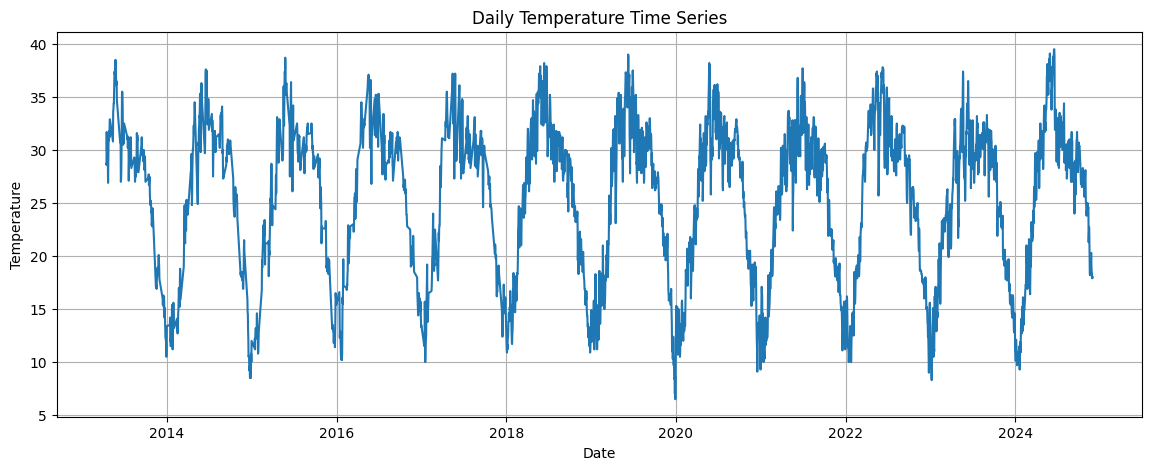

In [11]:
plt.figure(figsize=(14,5))
plt.plot(df["temp"])
plt.title("Daily Temperature Time Series")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.grid()
plt.show()

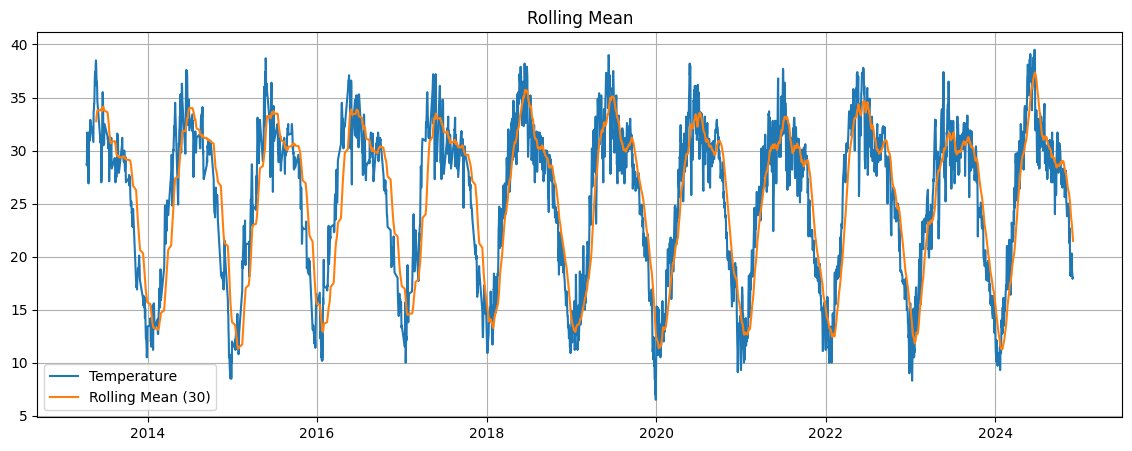

In [12]:
df["rolling_mean"] = df["temp"].rolling(window=30).mean()

plt.figure(figsize=(14,5))
plt.plot(df["temp"], label="Temperature")
plt.plot(df["rolling_mean"], label="Rolling Mean (30)")
plt.title("Rolling Mean")
plt.legend()
plt.grid()
plt.show()

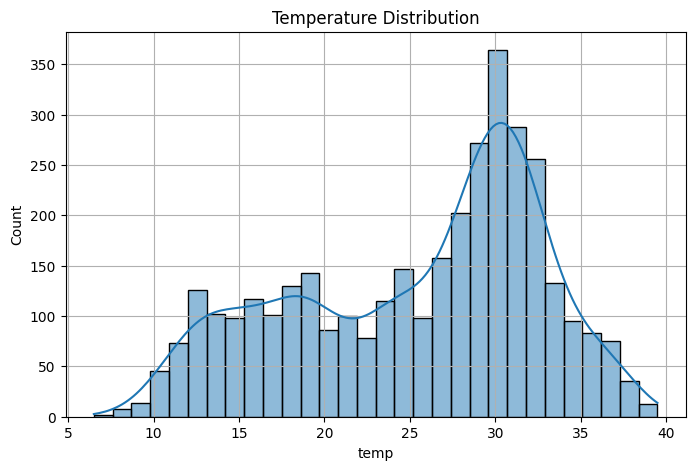

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["temp"], bins=30, kde=True)
plt.title("Temperature Distribution")
plt.grid()
plt.show()

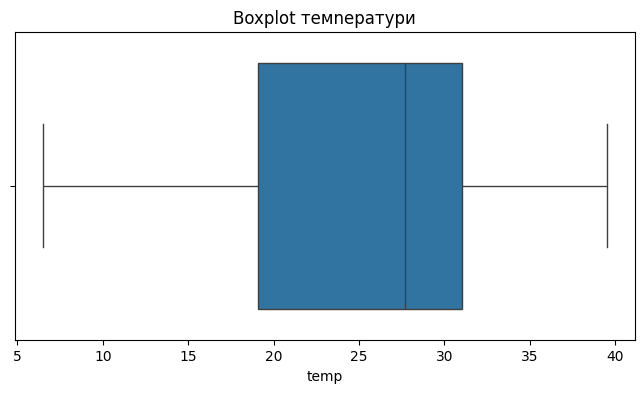

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["temp"])
plt.title("Boxplot тeмnepaтypи")
plt.show()

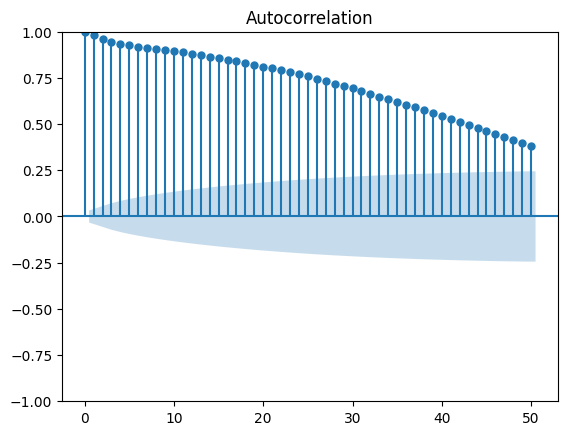

In [15]:
plot_acf(df["temp"], lags=50)
plt.show()

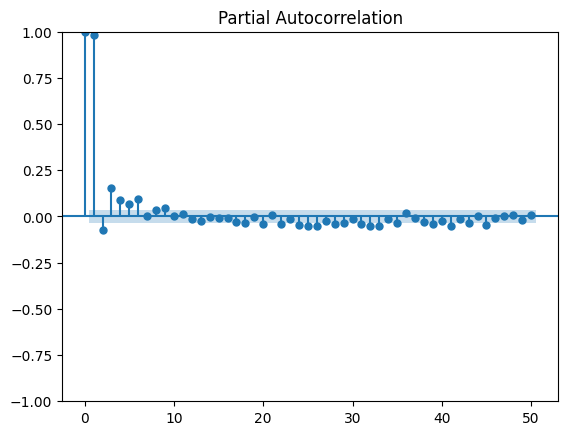

In [16]:
plot_pacf(df["temp"], lags=50)
plt.show()

In [17]:
target = df["temp"].copy()

split_index = int(len(target) * 0.8)

train = target.iloc[:split_index]
test = target.iloc[split_index:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2845
Test size: 712


In [18]:
arima_model = ARIMA(train, order=(5, 1, 2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

print(arima_forecast.head())

DATE
2022-12-20    14.895737
2022-12-21    15.071189
2022-12-22    15.161451
2022-12-23    15.179429
2022-12-24    15.200756
Name: predicted_mean, dtype: float64


In [19]:
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                 2845
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -4969.050
Date:                Thu, 12 Mar 2026   AIC                           9954.101
Time:                        10:20:46   BIC                          10001.724
Sample:                             0   HQIC                          9971.277
                               - 2845                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1810      0.227      0.799      0.424      -0.263       0.625
ar.L2          0.1094      0.205      0.533      0.594      -0.293       0.511
ar.L3         -0.1108      0.049     -2.242      0.0

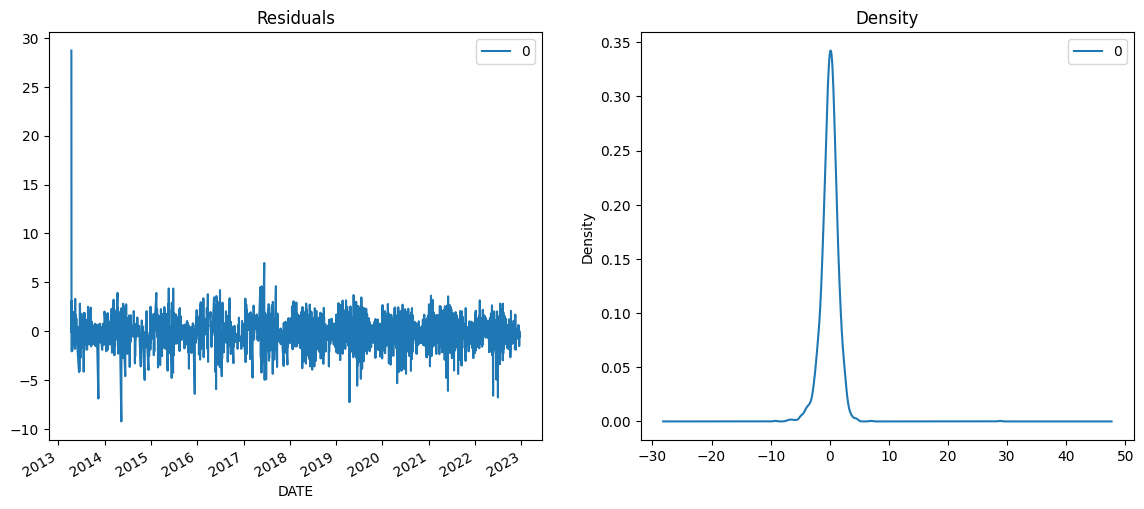

In [20]:
import pandas as pd

residuals = pd.DataFrame(arima_fit.resid)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

In [21]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = mape(test, arima_forecast)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAPE:", arima_mape)

ARIMA MAE: 10.92780939502283
ARIMA RMSE: 12.500912042764613
ARIMA MAPE: 39.59198711988373


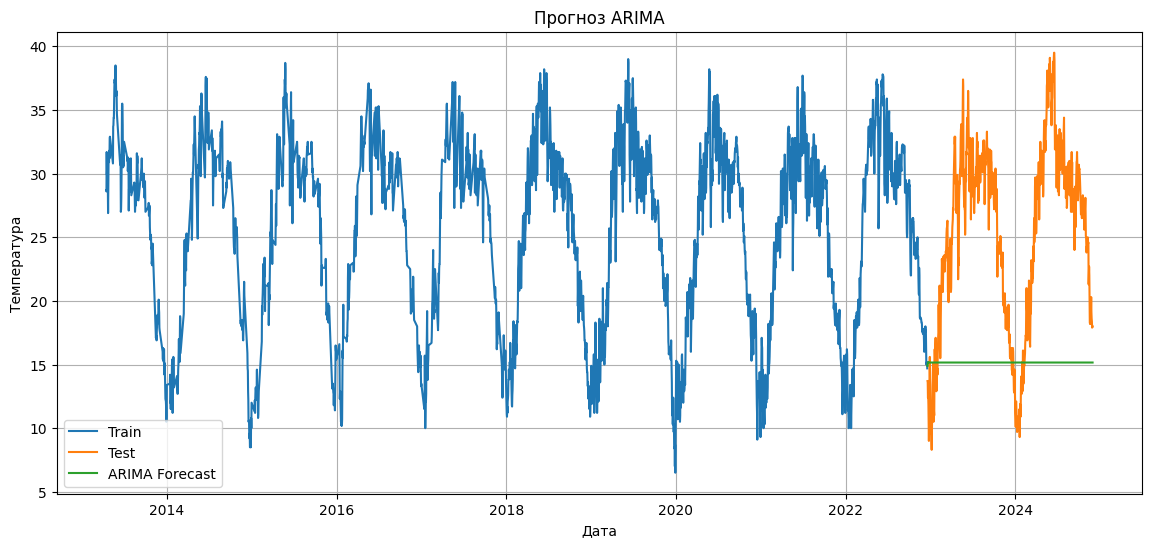

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast")
plt.title("Прогноз ARIMA")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
prophet_df = df.reset_index()[["DATE", "temp"]].copy()
prophet_df.columns = ["ds", "y"]

prophet_train = prophet_df.iloc[:split_index].copy()
prophet_test = prophet_df.iloc[split_index:].copy()

In [24]:
from prophet import Prophet

prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(prophet_train)

In [25]:
future = prophet_model.make_future_dataframe(periods=len(prophet_test), freq="D")
prophet_forecast_full = prophet_model.predict(future)

prophet_forecast = prophet_forecast_full[["ds", "yhat"]].tail(len(prophet_test)).copy()
prophet_forecast = prophet_forecast.set_index("ds")

prophet_test_indexed = prophet_test.set_index("ds")

In [26]:
prophet_mae = mean_absolute_error(prophet_test_indexed["y"], prophet_forecast["yhat"])
prophet_rmse = np.sqrt(mean_squared_error(prophet_test_indexed["y"], prophet_forecast["yhat"]))
prophet_mape = mape(prophet_test_indexed["y"], prophet_forecast["yhat"])

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)
print("Prophet MAPE:", prophet_mape)

Prophet MAE: 2.002177588726817
Prophet RMSE: 2.5872670693335067
Prophet MAPE: 9.014446237917445


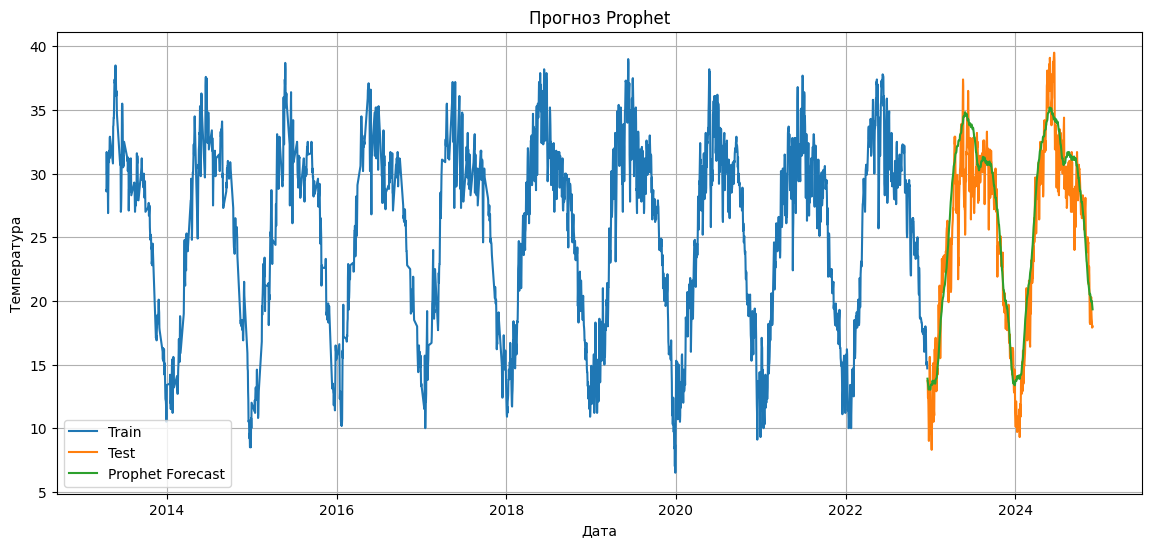

In [27]:
plt.figure(figsize=(14, 6))
plt.plot(prophet_train["ds"], prophet_train["y"], label="Train")
plt.plot(prophet_test["ds"], prophet_test["y"], label="Test")
plt.plot(prophet_forecast.index, prophet_forecast["yhat"], label="Prophet Forecast")
plt.title("Прогноз Prophet")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.legend()
plt.grid(True)
plt.show()

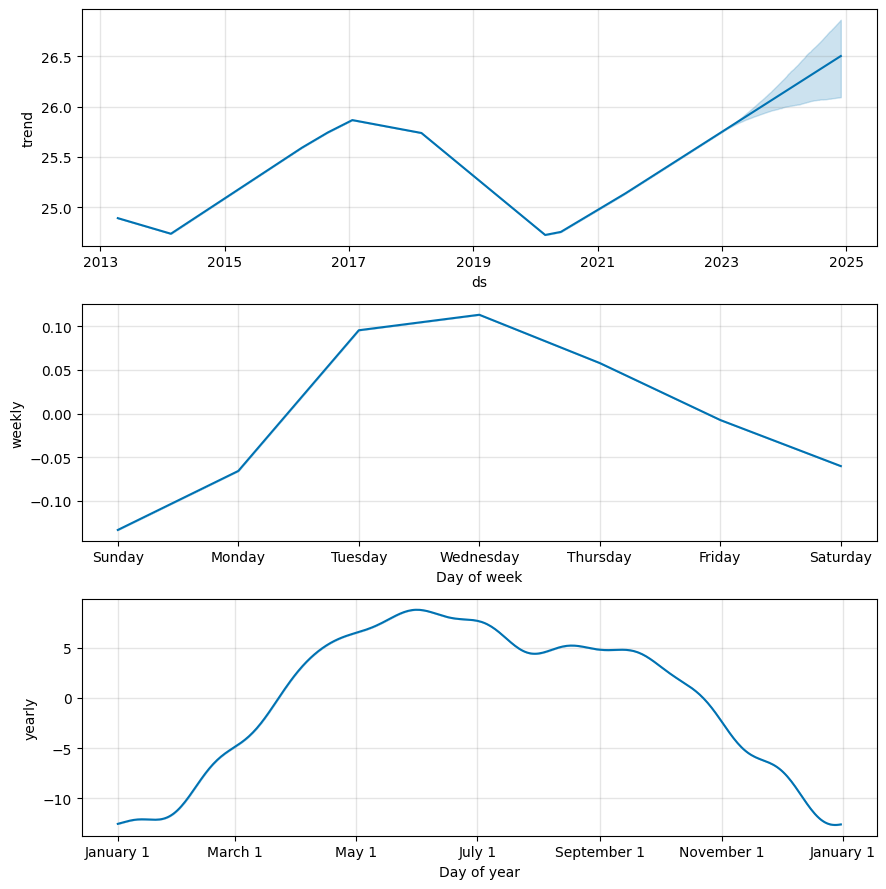

In [28]:
prophet_model.plot_components(prophet_forecast_full)
plt.show()

In [29]:
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df[["temp"]])

sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_values)):
    X.append(scaled_values[i-sequence_length:i, 0])
    y.append(scaled_values[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3527, 30, 1)
y shape: (3527,)


In [30]:
split_lstm = int(len(X) * 0.8)

X_train = X[:split_lstm]
X_test = X[split_lstm:]

y_train = y[:split_lstm]
y_test = y[split_lstm:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (2821, 30, 1)
X_test: (706, 30, 1)


In [31]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(LSTM(50))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam", loss="mse")

In [32]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - loss: 0.0621 - val_loss: 0.0054
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0063 - val_loss: 0.0055
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0057 - val_loss: 0.0044
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0054 - val_loss: 0.0047
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0046 - val_loss: 0.0040
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0044 - val_loss: 0.0039
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0048 - val_loss: 0.0035
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0043 - val_loss: 0.0034
Epoch 9/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0039 - val_loss: 0.0030
Epoch 10/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0037 - val_loss: 0.0031


In [33]:
lstm_model. summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

In [34]:
lstm_pred_scaled = lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step


In [35]:
lstm_dates = df.index[sequence_length:][split_lstm:]

In [36]:
lstm_mae = mean_absolute_error(y_test_real, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_real, lstm_pred))
lstm_mape = mape(y_test_real.flatten(), lstm_pred.flatten())

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)
print("LSTM MAPE:", lstm_mape)

LSTM MAE: 1.4600528509015747
LSTM RMSE: 1.8324714258445127
LSTM MAPE: 6.170582614319315


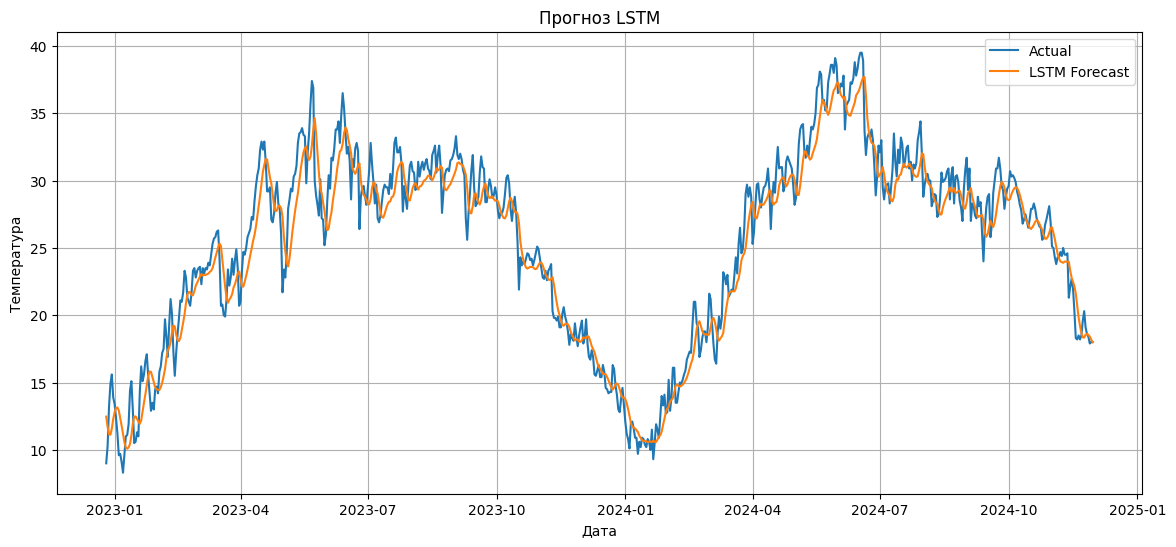

In [37]:
plt.figure(figsize=(14, 6))
plt.plot(lstm_dates, y_test_real, label="Actual")
plt.plot(lstm_dates, lstm_pred, label="LSTM Forecast")
plt.title("Прогноз LSTM")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet", "LSTM"],
    "MAE": [arima_mae, prophet_mae, lstm_mae],
    "RMSE": [arima_rmse, prophet_rmse, lstm_rmse],
    "MAPE": [arima_mape, prophet_mape, lstm_mape]
})

print(results.sort_values("RMSE"))

     Model        MAE       RMSE       MAPE
2     LSTM   1.460053   1.832471   6.170583
1  Prophet   2.002178   2.587267   9.014446
0    ARIMA  10.927809  12.500912  39.591987


Висновок: При виконанні лабораторної роботи я проаналізовав динаміку температур. Провів візуалізацію часового ряду, для прогнозування застосовано моделі ARIMA, Prophet та LSTM. Порівняльний аналіз за метриками MAE, RMSE та MAPE показав, що найвищу точність прогнозу забезпечує модель LSTM.